In [1]:
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
import warnings
# 忽略来自 torch.profiler 的警告，保持控制台整洁
warnings.filterwarnings("ignore", category=UserWarning, module="torch.profiler")

In [3]:
# ============================================================
# basic config
# ============================================================
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_MODE = "sparam"          # "sparam" / "mag" / "db"
BATCH_SIZE = 512                 # fixed as requested
LEARNING_RATE = 3.5e-4          # fixed as requested
TOTAL_ROUNDS = 1              # adjust yourself
TEST_RATIO = 0.1                # train/test split at circuit level
OVERLAP_RATIO = 0.25            # overlap for 4 circuit groups
SAVE_DIR = Path("./retrofl_surrogate_results")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [4]:
# ============================================================
# paths
# ============================================================
MATRIX_DIR = Path("./Auged_diag_dataset_pack_full")
TARGET_DIR = Path("./Auged_diag_dataset_pack_120")

In [5]:
# ============================================================
# best 3x3 model configs from your search results
# ============================================================
BEST_MODEL_CONFIGS = {
    ("MLP", "small"):  {"width": 256, "depth": 2},
    ("MLP", "medium"): {"width": 384, "depth": 3},
    ("MLP", "large"):  {"width": 512, "depth": 3},

    ("CNN", "small"):  {"width": 16, "depth": 2},
    ("CNN", "medium"): {"width": 48, "depth": 2},
    ("CNN", "large"):  {"width": 64, "depth": 3},

    ("ViT", "small"):  {"width": 64,  "depth": 2},
    ("ViT", "medium"): {"width": 128, "depth": 4},
    ("ViT", "large"):  {"width": 256, "depth": 4},
}

In [6]:
# ============================================================
# dataset utils
# ============================================================
def load_rf_pack(matrix_dir: Path, target_dir: Path, target_mode: str):
    matrix = np.load(matrix_dir / "matrix.npy")   # [N,1,H,W]
    freq = np.load(target_dir / "freq.npy")       # [Nf]

    if target_mode == "sparam":
        target = np.load(target_dir / "sparam.npy")   # [N,4,Nf]
    elif target_mode == "mag":
        target = np.load(target_dir / "mag.npy")      # [N,2,Nf]
    elif target_mode == "db":
        target = np.load(target_dir / "db.npy")       # [N,2,Nf]
    else:
        raise ValueError(f"Unknown TARGET_MODE: {target_mode}")

    if len(matrix) != len(target):
        raise ValueError(f"matrix samples {len(matrix)} != target samples {len(target)}")

    return {
        "matrix": matrix.astype(np.float32),
        "freq": freq.astype(np.float32),
        "target": target.astype(np.float32),
        "n_samples": len(matrix),
        "n_freq": target.shape[-1],
    }


def build_frequency_groups(n_freq: int, n_groups: int = 5) -> List[np.ndarray]:
    return [np.arange(i, n_freq, n_groups, dtype=np.int64) for i in range(n_groups)]


def build_overlapping_circuit_groups(circuit_indices: np.ndarray, n_groups: int = 4, overlap_ratio: float = 0.25):
    """
    Split train circuits into 4 groups with mild overlap.
    Chosen policy:
      - contiguous windows on shuffled train circuits
      - neighboring windows overlap by overlap_ratio * window_size
    """
    circuit_indices = np.asarray(circuit_indices, dtype=np.int64)
    n = len(circuit_indices)
    if n_groups == 1:
        return [circuit_indices.copy()]

    window = int(math.ceil(n / n_groups))
    overlap = int(round(window * overlap_ratio))
    step = max(1, window - overlap)

    groups = []
    start = 0
    for g in range(n_groups):
        end = min(start + window, n)
        part = circuit_indices[start:end]
        if len(part) == 0:
            part = circuit_indices[max(0, n - window):n]
        groups.append(np.asarray(part, dtype=np.int64))
        start += step
        if start >= n:
            start = max(0, n - window)

    return groups


class ClientFreqDataset(Dataset):
    def __init__(self, matrix: np.ndarray, target: np.ndarray, circuit_indices: np.ndarray, freq_indices: np.ndarray):
        self.matrix = matrix
        self.target = target
        self.circuit_indices = np.asarray(circuit_indices, dtype=np.int64)
        self.freq_indices = np.asarray(freq_indices, dtype=np.int64)

    def __len__(self):
        return len(self.circuit_indices)

    def __getitem__(self, idx):
        ci = int(self.circuit_indices[idx])
        x = self.matrix[ci]                              # [1,H,W]
        y = self.target[ci][:, self.freq_indices]        # [C,Nf_sub]
        return {
            "matrix": torch.as_tensor(x, dtype=torch.float32),
            "freq_index": torch.as_tensor(self.freq_indices, dtype=torch.long),
            "target": torch.as_tensor(y, dtype=torch.float32),
            "sample_index": ci,
        }


class FullFreqDataset(Dataset):
    def __init__(self, matrix: np.ndarray, target: np.ndarray, circuit_indices: np.ndarray):
        self.matrix = matrix
        self.target = target
        self.circuit_indices = np.asarray(circuit_indices, dtype=np.int64)
        self.freq_indices = np.arange(target.shape[-1], dtype=np.int64)

    def __len__(self):
        return len(self.circuit_indices)

    def __getitem__(self, idx):
        ci = int(self.circuit_indices[idx])
        x = self.matrix[ci]
        y = self.target[ci]
        return {
            "matrix": torch.as_tensor(x, dtype=torch.float32),
            "freq_index": torch.as_tensor(self.freq_indices, dtype=torch.long),
            "target": torch.as_tensor(y, dtype=torch.float32),
            "sample_index": ci,
        }


def make_client_specs(train_indices: np.ndarray, n_clients: int, n_freq: int, overlap_ratio: float = 0.25):
    freq_groups = build_frequency_groups(n_freq=n_freq, n_groups=5)
    circuit_groups = build_overlapping_circuit_groups(train_indices, n_groups=4, overlap_ratio=overlap_ratio)

    specs = []
    if n_clients == 3:
        # same circuit subset, first 3 freq groups
        circ = circuit_groups[0]
        for i in range(3):
            specs.append({
                "client_id": f"C{i}",
                "circuit_group_id": 0,
                "freq_group_id": i,
                "circuit_indices": circ,
                "freq_indices": freq_groups[i],
            })
    elif n_clients == 5:
        circ = circuit_groups[0]
        for i in range(5):
            specs.append({
                "client_id": f"C{i}",
                "circuit_group_id": 0,
                "freq_group_id": i,
                "circuit_indices": circ,
                "freq_indices": freq_groups[i],
            })
    elif n_clients == 10:
        for cg in range(2):
            for fg in range(5):
                specs.append({
                    "client_id": f"G{cg}F{fg}",
                    "circuit_group_id": cg,
                    "freq_group_id": fg,
                    "circuit_indices": circuit_groups[cg],
                    "freq_indices": freq_groups[fg],
                })
    elif n_clients == 20:
        for cg in range(4):
            for fg in range(5):
                specs.append({
                    "client_id": f"G{cg}F{fg}",
                    "circuit_group_id": cg,
                    "freq_group_id": fg,
                    "circuit_indices": circuit_groups[cg],
                    "freq_indices": freq_groups[fg],
                })
    else:
        raise ValueError("n_clients must be one of {3,5,10,20}")

    return specs

In [7]:
# ============================================================
# models
# ============================================================
class FrequencyEmbedding(nn.Module):
    def __init__(self, num_freqs=120, embed_dim=64):
        super().__init__()
        self.embed = nn.Embedding(num_freqs, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, embed_dim),
        )

    def forward(self, freq_idx):
        x = self.embed(freq_idx)
        x = self.norm(x)
        x = self.mlp(x)
        return x


class SearchableMLPFreqSurrogate(nn.Module):
    def __init__(self, n_rows=16, n_cols=16, width=256, depth=3, freq_dim=64, dropout=0.3, num_freqs=120, out_dim=4):
        super().__init__()
        input_dim = n_rows * n_cols

        encoder_layers = []
        in_dim = input_dim
        for _ in range(depth):
            encoder_layers += [nn.Linear(in_dim, width), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            in_dim = width
        self.structure_encoder = nn.Sequential(*encoder_layers)

        self.freq_embed = FrequencyEmbedding(num_freqs=num_freqs, embed_dim=freq_dim)

        head_layers = []
        in_dim = width + freq_dim
        for _ in range(depth):
            head_layers += [nn.Linear(in_dim, width), nn.GELU(), nn.Dropout(dropout)]
            in_dim = width
        head_layers.append(nn.Linear(in_dim, out_dim))
        self.head = nn.Sequential(*head_layers)
        self.out_act = nn.Tanh()

    def encode_structure(self, matrix):
        x = matrix.flatten(1)
        return self.structure_encoder(x)

    def forward(self, matrix, freq):
        struct_feat = self.encode_structure(matrix)
        freq_feat = self.freq_embed(freq)
        B, Nf, Df = freq_feat.shape
        Ds = struct_feat.shape[1]
        struct_feat = struct_feat.unsqueeze(1).expand(B, Nf, Ds)
        fusion = torch.cat([struct_feat, freq_feat], dim=-1)
        out = self.head(fusion)
        out = self.out_act(out)
        return out.transpose(1, 2)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.GroupNorm(num_groups=8, num_channels=out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class SearchableResNetFeatureExtractor(nn.Module):
    def __init__(self, base_channels=32, depth=2, out_dim=256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, base_channels, 3, 1, 1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=base_channels),
            nn.ReLU(inplace=True),
        )
        layer1 = []
        in_ch = base_channels
        for _ in range(depth):
            layer1.append(ResidualBlock(in_ch, base_channels, stride=1))
            in_ch = base_channels
        self.layer1 = nn.Sequential(*layer1)
        layer2 = []
        for i in range(depth):
            stride = 2 if i == 0 else 1
            layer2.append(ResidualBlock(in_ch, base_channels * 2, stride=stride))
            in_ch = base_channels * 2
        self.layer2 = nn.Sequential(*layer2)
        layer3 = []
        for i in range(depth):
            stride = 2 if i == 0 else 1
            layer3.append(ResidualBlock(in_ch, out_dim, stride=stride))
            in_ch = out_dim
        self.layer3 = nn.Sequential(*layer3)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = x.flatten(1)
        return x


class SearchableResNetFreqSurrogate(nn.Module):
    def __init__(self, width=32, depth=2, freq_dim=64, structure_dim=256, head_width=256, head_depth=2, dropout=0.3, num_freqs=120):
        super().__init__()
        self.feature_extractor = SearchableResNetFeatureExtractor(base_channels=width, depth=depth, out_dim=structure_dim)
        self.freq_embed = FrequencyEmbedding(num_freqs=num_freqs, embed_dim=freq_dim)
        head_layers = []
        in_dim = structure_dim + freq_dim
        for _ in range(head_depth):
            head_layers += [nn.Linear(in_dim, head_width), nn.GELU(), nn.Dropout(dropout)]
            in_dim = head_width
        head_layers.append(nn.Linear(in_dim, 4))
        self.head = nn.Sequential(*head_layers)
        self.out_act = nn.Tanh()

    def forward(self, matrix, freq):
        struct_feat = self.feature_extractor(matrix)
        freq_feat = self.freq_embed(freq)
        B, Nf, Df = freq_feat.shape
        Ds = struct_feat.shape[1]
        struct_feat = struct_feat.unsqueeze(1).expand(B, Nf, Ds)
        fusion = torch.cat([struct_feat, freq_feat], dim=-1)
        out = self.head(fusion)
        out = self.out_act(out)
        return out.transpose(1, 2)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class SearchableCNNFeatureExtractor(nn.Module):
    def __init__(self, embed_dim=128, depth=3):
        super().__init__()
        chs = [1]
        if depth == 1:
            chs += [embed_dim]
        elif depth == 2:
            chs += [embed_dim // 2, embed_dim]
        else:
            mid = max(embed_dim // 4, 32)
            mid2 = max(embed_dim // 2, 64)
            chs += [mid, mid2]
            while len(chs) < depth:
                chs.append(embed_dim)
            chs = chs[:depth] + [embed_dim]

        seq = []
        for i in range(len(chs) - 1):
            k = 5 if i == 0 else 3
            p = 2 if i == 0 else 1
            seq += [
                nn.Conv2d(chs[i], chs[i + 1], kernel_size=k, stride=1, padding=p, bias=False),
                nn.GroupNorm(num_groups=8, num_channels=chs[i + 1]),
                nn.ReLU(inplace=True),
            ]
        self.net = nn.Sequential(*seq)

    def forward(self, x):
        return self.net(x)


class PatchEmbedding4x4(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.proj = nn.Conv2d(embed_dim, embed_dim, kernel_size=4, stride=4, padding=0, bias=True)

    def forward(self, x):
        B, C, H, W = x.shape
        pad_h = (4 - H % 4) % 4
        pad_w = (4 - W % 4) % 4
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class SearchableFrequencyQueryEMSurrogate(nn.Module):
    def __init__(self, width=128, depth=4, cnn_depth=3, ff_mult=4, dropout=0.3, num_freqs=120):
        super().__init__()
        embed_dim = width
        if embed_dim % 8 != 0:
            raise ValueError(f"embed_dim={embed_dim} must be divisible by 8")

        num_heads = min(8, embed_dim // 32 if embed_dim >= 64 else 2)
        num_heads = max(num_heads, 2)
        while embed_dim % num_heads != 0 and num_heads > 1:
            num_heads -= 1
        ff_dim = ff_mult * embed_dim

        self.feature_extractor = SearchableCNNFeatureExtractor(embed_dim=embed_dim, depth=cnn_depth)
        self.patch_embed = PatchEmbedding4x4(embed_dim=embed_dim)
        self.pos_enc = PositionalEncoding(embed_dim, max_len=128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="relu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer=encoder_layer, num_layers=depth)

        self.freq_embed = FrequencyEmbedding(num_freqs=num_freqs, embed_dim=64)
        self.query_proj = nn.Linear(64, embed_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="relu", batch_first=True, norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer=decoder_layer, num_layers=depth)

        self.head_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, 4),
        )
        self.out_act = nn.Tanh()

    def encode_structure(self, matrix):
        feat = self.feature_extractor(matrix)
        tokens = self.patch_embed(feat)
        tokens = self.pos_enc(tokens)
        memory = self.encoder(tokens)
        return memory

    def decode_query(self, memory, freq_idx):
        B, Nf = freq_idx.shape
        q = self.freq_embed(freq_idx)
        q = self.query_proj(q)
        tgt_mask = ~torch.eye(Nf, Nf, dtype=torch.bool, device=q.device)
        dec = self.decoder(tgt=q, memory=memory, tgt_mask=tgt_mask)
        dec = self.head_norm(dec)
        out = self.head(dec)
        out = self.out_act(out)
        return out.transpose(1, 2)

    def forward(self, matrix, freq):
        memory = self.encode_structure(matrix)
        return self.decode_query(memory, freq)

In [8]:
# ============================================================
# build model / metrics / flops
# ============================================================
def build_model(arch: str, size_bucket: str, n_rows: int, n_cols: int, num_freqs: int):
    cfg = BEST_MODEL_CONFIGS[(arch, size_bucket)]

    if arch == "MLP":
        return SearchableMLPFreqSurrogate(
            n_rows=n_rows, n_cols=n_cols,
            width=cfg["width"], depth=cfg["depth"],
            freq_dim=64, dropout=0.3, num_freqs=num_freqs,
        ).to(DEVICE)
    elif arch == "CNN":
        return SearchableResNetFreqSurrogate(
            width=cfg["width"], depth=cfg["depth"],
            freq_dim=64,
            structure_dim=max(128, cfg["width"] * 4),
            head_width=max(128, cfg["width"] * 4),
            head_depth=2, dropout=0.3, num_freqs=num_freqs,
        ).to(DEVICE)
    elif arch == "ViT":
        return SearchableFrequencyQueryEMSurrogate(
            width=cfg["width"], depth=cfg["depth"],
            cnn_depth=3, ff_mult=4, dropout=0.3, num_freqs=num_freqs,
        ).to(DEVICE)
    else:
        raise ValueError(arch)


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model: nn.Module) -> float:
    total_bytes = 0
    for p in model.parameters():
        total_bytes += p.numel() * p.element_size()
    for b in model.buffers():
        total_bytes += b.numel() * b.element_size()
    return total_bytes / (1024 ** 2)


@torch.no_grad()
def compute_r2(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    ss_res = 0.0
    y_sum = 0.0
    y_sq_sum = 0.0
    n_elem = 0
    for batch in loader:
        matrices = batch["matrix"].to(DEVICE, non_blocking=True)
        freq_indices = batch["freq_index"].to(DEVICE, dtype=torch.long, non_blocking=True)
        targets = batch["target"].to(DEVICE, non_blocking=True)
        pred = model(matrices, freq_indices)
        diff = pred - targets
        ss_res += float((diff * diff).sum().item())
        y_sum += float(targets.sum().item())
        y_sq_sum += float((targets * targets).sum().item())
        n_elem += int(targets.numel())

    if n_elem == 0:
        return float("nan")
    y_mean = y_sum / n_elem
    ss_tot = y_sq_sum - n_elem * (y_mean ** 2)
    if abs(ss_tot) < 1e-12:
        return float("nan")
    return 1.0 - ss_res / ss_tot


def compute_train_r2_on_loader(model: nn.Module, loader: DataLoader) -> float:
    return compute_r2(model, loader)


def estimate_flops(model: nn.Module, n_rows: int, n_cols: int, num_freqs_sub: int, batch_size: int) -> float:
    """
    Return FLOPs for one forward pass using the same tensor shape as training.
    """
    model.eval()
    x = torch.randn(batch_size, 1, n_rows, n_cols, device=DEVICE)
    f = torch.randint(0, max(1, num_freqs_sub), (batch_size, num_freqs_sub), device=DEVICE, dtype=torch.long)

    try:
        with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.CPU], with_flops=True) as prof:
            with torch.no_grad():
                _ = model(x, f)
        total_flops = 0
        for evt in prof.key_averages():
            if hasattr(evt, "flops") and evt.flops is not None:
                total_flops += evt.flops
        return float(total_flops)
    except Exception:
        return float("nan")

In [ ]:
# ============================================================
# retroFL generalized to image+multi-frequency surrogate
# ============================================================
class ParaServer:
    def __init__(self, model: nn.Module, learning_rate: float):
        self.model = model.to(DEVICE)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=TOTAL_ROUNDS, eta_min=1e-6)
        self.client_scores: Dict[str, float] = {}

    def upload(self, grads: List[torch.Tensor], client_id: str, score: float):
        self.client_scores[client_id] = max(0.0, float(score))
        self.optimizer.zero_grad(set_to_none=True)
        for p, g in zip(self.model.parameters(), grads):
            p.grad = g.detach()
        self.optimizer.step()
        return self.download()

    def download(self):
        s_d = self.model.state_dict()
        return s_d


class RetroClient:
    def __init__(self, client_id: str, train_loader: DataLoader, all_freq_groups: List[np.ndarray], my_freq_group_id: int):
        self.client_id = client_id
        self.train_loader = train_loader
        self.all_freq_groups = [np.asarray(g, dtype=np.int64) for g in all_freq_groups]
        self.my_freq_group_id = my_freq_group_id
        self.anchor_model = None
        self.other_scores: Dict[str, float] = {}

    def train_one_round(self, ps: ParaServer, model_builder, global_round: int, first_epoch: bool = False):
        if first_epoch:
            self.anchor_model = model_builder().to(DEVICE)
            self.anchor_model.load_state_dict(ps.download())

            self.anchor_model.eval()
            self.other_scores = dict(ps.client_scores)

        model = model_builder().to(DEVICE)
        model.load_state_dict(ps.download())
        model.train()

        for batch in self.train_loader:
            matrices = batch["matrix"].to(DEVICE, non_blocking=True)
            freq_indices = batch["freq_index"].to(DEVICE, dtype=torch.long, non_blocking=True)
            targets = batch["target"].to(DEVICE, non_blocking=True)

            model.zero_grad(set_to_none=True)
            pred = model(matrices, freq_indices)
            tr_mse = F.mse_loss(pred, targets)
            tr_mse.backward()
            grads = [p.grad.detach().clone() for p in model.parameters()]

            # local train r2 on this batch
            ss_res = torch.sum((pred - targets) ** 2)
            y_mean = torch.mean(targets)
            ss_tot = torch.sum((targets - y_mean) ** 2)
            if torch.abs(ss_tot) < 1e-12:
                tr_r2 = torch.tensor(0.0, device=DEVICE)
            else:
                tr_r2 = 1 - ss_res / ss_tot

            sum_r2 = 1.0
            if self.anchor_model is not None:
                for other_client_id, weight in self.other_scores.items():
                    if other_client_id == self.client_id or abs(weight) < 1e-12:
                        continue

                    # parse other freq group id from the key cache if possible
                    # cache stores all clients individually; here we use every other client's current score.
                    # for the pseudo target, reuse the current matrices but query the other client's frequency group.
                    # because the surrogate can evaluate arbitrary frequency subsets for a given circuit.
                    try:
                        fg = int(str(other_client_id).split("F")[-1]) if "F" in str(other_client_id) else None
                    except Exception:
                        fg = None
                    if fg is None:
                        # for 3-client case client ids are C0/C1/C2 and directly map to freq groups 0,1,2
                        if str(other_client_id).startswith("C"):
                            fg = int(str(other_client_id)[1:])
                        else:
                            continue

                    other_freq_idx = torch.as_tensor(self.all_freq_groups[fg], dtype=torch.long, device=DEVICE).unsqueeze(0)
                    other_freq_idx = other_freq_idx.expand(matrices.shape[0], -1)

                    with torch.no_grad():
                        y_anchor = self.anchor_model(matrices, other_freq_idx)

                    model.zero_grad(set_to_none=True)
                    y_pred_other = model(matrices, other_freq_idx)
                    loss_other = F.mse_loss(y_pred_other, y_anchor)
                    loss_other.backward()
                    grad_other = [p.grad.detach().clone() for p in model.parameters()]
                    grads = [g + go * float(weight) for g, go in zip(grads, grad_other)]
                    sum_r2 += float(weight)

            avg_grads = [g / sum_r2 for g in grads]
            model.load_state_dict(ps.upload(avg_grads, self.client_id, float(tr_r2.detach().item())))

        train_r2 = compute_train_r2_on_loader(model, self.train_loader)
        # print(f"client {self.client_id} | round {global_round} | train_r2 {train_r2:.6f}")
        return train_r2

In [10]:
import random
from dataclasses import dataclass

@dataclass
class ClientScheduleState:
    is_online: bool
    remaining_rounds: int


class OnlineOfflineScheduler:
    """
    更贴近现实的节点上线/下线调度器：
    - 节点一旦上线，会连续在线若干轮
    - 节点一旦下线，会连续离线若干轮
    - 每轮返回当前在线的客户端列表
    """

    def __init__(
        self,
        num_clients,
        online_span_range=(3, 8),     # 每次上线持续多少轮
        offline_span_range=(5, 20),   # 每次下线持续多少轮
        init_online_prob=0.5,
        min_online_clients=1,
        seed=42,
    ):
        self.num_clients = num_clients
        self.online_span_range = online_span_range
        self.offline_span_range = offline_span_range
        self.min_online_clients = min_online_clients
        self.rng = random.Random(seed)

        self.states = []
        for _ in range(num_clients):
            is_online = self.rng.random() < init_online_prob
            span = self._sample_online_span() if is_online else self._sample_offline_span()
            self.states.append(ClientScheduleState(is_online=is_online, remaining_rounds=span))

    def _sample_online_span(self):
        return self.rng.randint(self.online_span_range[0], self.online_span_range[1])

    def _sample_offline_span(self):
        return self.rng.randint(self.offline_span_range[0], self.offline_span_range[1])

    def _flip_state(self, idx):
        st = self.states[idx]
        if st.is_online:
            st.is_online = False
            st.remaining_rounds = self._sample_offline_span()
        else:
            st.is_online = True
            st.remaining_rounds = self._sample_online_span()

    def get_online_clients(self):
        online = [i for i, st in enumerate(self.states) if st.is_online]

        # 防止某一轮一个在线客户端都没有
        if len(online) < self.min_online_clients:
            offline_ids = [i for i, st in enumerate(self.states) if not st.is_online]
            self.rng.shuffle(offline_ids)
            need = self.min_online_clients - len(online)
            for idx in offline_ids[:need]:
                self.states[idx].is_online = True
                self.states[idx].remaining_rounds = self._sample_online_span()
            online = [i for i, st in enumerate(self.states) if st.is_online]

        return online

    def step(self):
        """
        一轮结束后推进状态
        """
        for idx, st in enumerate(self.states):
            st.remaining_rounds -= 1
            if st.remaining_rounds <= 0:
                self._flip_state(idx)

In [11]:
# ============================================================
# experiment runner
# ============================================================
def build_dataloaders_for_experiment(pack, n_clients: int):
    n_total = pack["n_samples"]
    all_indices = np.arange(n_total, dtype=np.int64)
    train_indices, test_indices = train_test_split(
        all_indices,
        test_size=TEST_RATIO,
        random_state=RANDOM_SEED,
        shuffle=True,
    )

    client_specs = make_client_specs(train_indices, n_clients=n_clients, n_freq=pack["n_freq"], overlap_ratio=OVERLAP_RATIO)
    freq_groups = build_frequency_groups(pack["n_freq"], n_groups=5)

    client_loaders = []
    for spec in client_specs:
        ds = ClientFreqDataset(
            matrix=pack["matrix"],
            target=pack["target"],
            circuit_indices=spec["circuit_indices"],
            freq_indices=spec["freq_indices"],
        )
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=False)
        client_loaders.append((spec, loader))

    test_ds = FullFreqDataset(pack["matrix"], pack["target"], test_indices)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    return client_loaders, test_loader, train_indices, test_indices, freq_groups

def make_live_plotter():
    handle = display(None, display_id=True)

    def update(
        global_r2_history,
        client_r2_history,
        client_window_start_marks,
        arch,
        size_bucket,
        n_clients,
        global_round,
        total_rounds,
    ):
        fig, ax = plt.subplots(figsize=(8, 4.8))

        # global test R2: stronger line
        x = np.arange(len(global_r2_history))
        ax.plot(x, global_r2_history, linewidth=2.2, label="Global Test R2")

        # client R2: lighter lines
        for client_id, hist in client_r2_history.items():
            hist = np.asarray(hist, dtype=np.float64)
            cx = np.arange(len(hist))

            line, = ax.plot(
                cx,
                hist,
                linewidth=1.5,
                alpha=0.45,
                label=f"{client_id} R2",
            )

            # mark the first round of each online window
            start_rounds = client_window_start_marks.get(client_id, [])
            start_x = []
            start_y = []
            for r in start_rounds:
                if 0 <= r < len(hist) and not np.isnan(hist[r]):
                    start_x.append(r)
                    start_y.append(hist[r])

            if len(start_x) > 0:
                ax.scatter(
                    start_x,
                    start_y,
                    s=28,
                    alpha=0.9,
                    color=line.get_color(),
                    zorder=3,
                )

        ax.set_xlabel("Round")
        ax.set_ylabel("R2")
        ax.set_title(f"{arch}-{size_bucket}-{n_clients} clients | round {global_round + 1}/{total_rounds}")
        ax.grid(True, alpha=0.3)

        if len(global_r2_history) > 0:
            ax.scatter(
                [len(global_r2_history) - 1],
                [global_r2_history[-1]],
                s=35,
                zorder=4,
            )
            ax.text(
                len(global_r2_history) - 1,
                global_r2_history[-1],
                f"{global_r2_history[-1]:.4f}",
                fontsize=9,
                ha="left",
                va="bottom",
            )

        ax.legend(loc="best", fontsize=8, ncol=2)
        plt.tight_layout()
        handle.update(fig)
        plt.close(fig)

    return update

def run_one_experiment(pack, arch: str, size_bucket: str, n_clients: int, total_rounds: int = TOTAL_ROUNDS):
    n_rows = int(pack["matrix"].shape[2])
    n_cols = int(pack["matrix"].shape[3])
    num_freqs = int(pack["n_freq"])

    def model_builder():
        return build_model(
            arch=arch,
            size_bucket=size_bucket,
            n_rows=n_rows,
            n_cols=n_cols,
            num_freqs=num_freqs,
        )

    base_model = model_builder()
    ps = ParaServer(base_model, learning_rate=LEARNING_RATE)

    client_loaders, test_loader, train_indices, test_indices, freq_groups = build_dataloaders_for_experiment(
        pack, n_clients=n_clients
    )

    clients = []
    client_prev_online = {}
    for spec, loader in client_loaders:
        clients.append(
            RetroClient(
                client_id=spec["client_id"],
                train_loader=loader,
                all_freq_groups=freq_groups,
                my_freq_group_id=spec["freq_group_id"],
            )
        )
        client_prev_online[spec["client_id"]] = False

    global_r2_history = []
    live_plot = make_live_plotter()

    client_r2_history = {client.client_id: [] for client in clients}
    client_window_start_marks = {client.client_id: [] for client in clients}

    client_scheduler = OnlineOfflineScheduler(
        num_clients=len(clients),
        online_span_range=(8, 16),
        offline_span_range=(4, 10),
        init_online_prob=0.6,
        min_online_clients=1,
        seed=42,
    )

    round_bar = tqdm(
        range(total_rounds),
        desc=f"{arch}-{size_bucket}-{n_clients}c",
        leave=True,
        dynamic_ncols=True,
    )

    for global_round in round_bar:
        online_ids = client_scheduler.get_online_clients()
        for client in clients:
            client_r2_history[client.client_id].append(np.nan)

        order = online_ids[:]
        random.shuffle(order)

        cur_train_r2 = []
        cur_client_id = []

        for idx in order:
            client = clients[idx]
            window_start = not client_prev_online[client.client_id]

            train_r2 = client.train_one_round(
                ps,
                model_builder=model_builder,
                global_round=global_round,
                first_epoch=window_start,
            )
            client_r2_history[client.client_id][-1] = float(train_r2)

            if window_start:
                client_window_start_marks[client.client_id].append(global_round)

            cur_train_r2.append(round(train_r2, 2))
            cur_client_id.append(client.client_id)

        for idx, client in enumerate(clients):
            client_prev_online[client.client_id] = (idx in online_ids)

        client_scheduler.step()
        ps.scheduler.step()

        global_model = model_builder().to(DEVICE)
        global_model.load_state_dict(ps.download())
        g_r2 = compute_r2(global_model, test_loader)
        global_r2_history.append(g_r2)

        current_lr = ps.optimizer.param_groups[0]["lr"]
        round_bar.set_postfix({
            "online": len(order),
            "last_client": cur_client_id if len(cur_client_id) > 0 else "-",
            "last_train_r2": cur_train_r2 if len(cur_train_r2) > 0 else "-",
            "global_r2": f"{g_r2:.4f}",
            "lr": f"{current_lr:.2e}",
        })
        live_plot(
            global_r2_history,
            client_r2_history,
            client_window_start_marks,
            arch=arch,
            size_bucket=size_bucket,
            n_clients=n_clients,
            global_round=global_round,
            total_rounds=total_rounds,
        )

    round_bar.close()

    param_count = count_trainable_params(ps.model)
    freq_groups = build_frequency_groups(pack["n_freq"], n_groups=5)
    num_freqs_sub = max(len(g) for g in freq_groups)
    flops = estimate_flops(
        ps.model,
        n_rows=n_rows,
        n_cols=n_cols,
        num_freqs_sub=num_freqs_sub,
        batch_size=BATCH_SIZE,
    )
    size_mb = model_size_mb(ps.model)
    final_r2 = float(global_r2_history[-1])
    tail_len = max(1, int(math.ceil(0.2 * len(global_r2_history))))
    tail_std = float(np.std(np.asarray(global_r2_history[-tail_len:], dtype=np.float64)))

    out = {
        "arch": arch,
        "size_bucket": size_bucket,
        "n_clients": n_clients,
        "final_r2": final_r2,
        "tail_std": tail_std,
        "n_params": int(param_count),
        "flops": float(flops),
        "model_size_mb": float(size_mb),
        "total_rounds": int(total_rounds),
        "train_circuits": int(len(train_indices)),
        "test_circuits": int(len(test_indices)),
    }

    save_name = f"{arch}_{size_bucket}_{n_clients}clients"
    np.savez(
        SAVE_DIR / f"{save_name}_history.npz",
        global_r2=np.asarray(global_r2_history, dtype=np.float32),
    )
    torch.save(ps.model.state_dict(), SAVE_DIR / f"{save_name}_final.pt")

    print(
        f"[DONE] {arch}-{size_bucket}-{n_clients}c | "
        f"final_r2={final_r2:.4f} | tail_std={tail_std:.4f}"
    )

    return out


def run_all_experiments():
    pack = load_rf_pack(MATRIX_DIR, TARGET_DIR, TARGET_MODE)
    rows = []
    for arch in ["MLP", "CNN", "ViT"]:
        for size_bucket in ["small", "medium", "large"]:
            for n_clients in [3, 5, 10, 20]:
                print("\n" + "=" * 90)
                print(f"RUN | arch={arch} | size={size_bucket} | clients={n_clients}")
                print("=" * 90)
                row = run_one_experiment(
                    pack,
                    arch=arch,
                    size_bucket=size_bucket,
                    n_clients=n_clients,
                    total_rounds=TOTAL_ROUNDS,
                )
                rows.append(row)
                pd.DataFrame(rows).to_csv(SAVE_DIR / "summary_results.csv", index=False)

    df = pd.DataFrame(rows)
    df.to_csv(SAVE_DIR / "summary_results.csv", index=False)
    print(df)
    return df


RUN | arch=MLP | size=small | clients=3


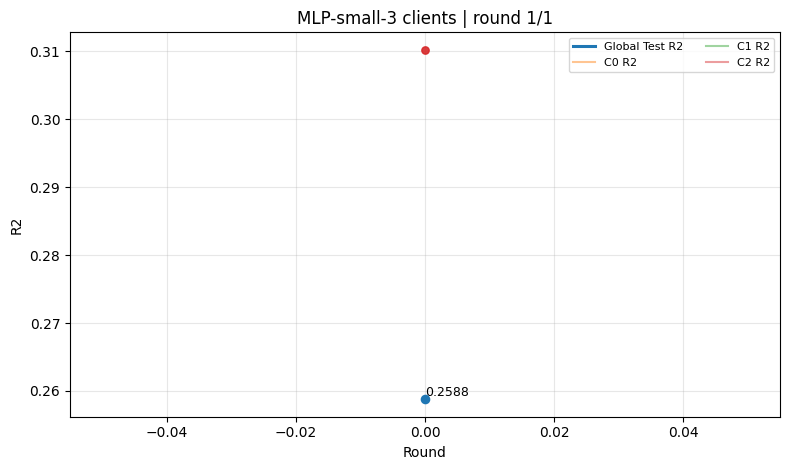

MLP-small-3c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-small-3c | final_r2=0.2588 | tail_std=0.0000

RUN | arch=MLP | size=small | clients=5


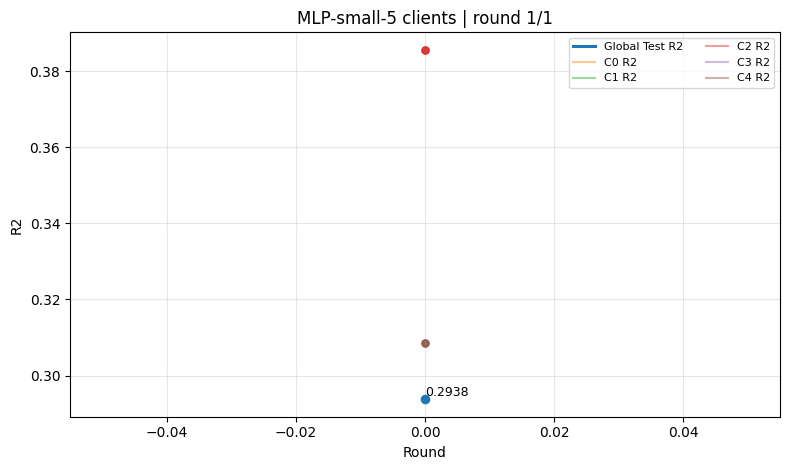

MLP-small-5c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-small-5c | final_r2=0.2938 | tail_std=0.0000

RUN | arch=MLP | size=small | clients=10


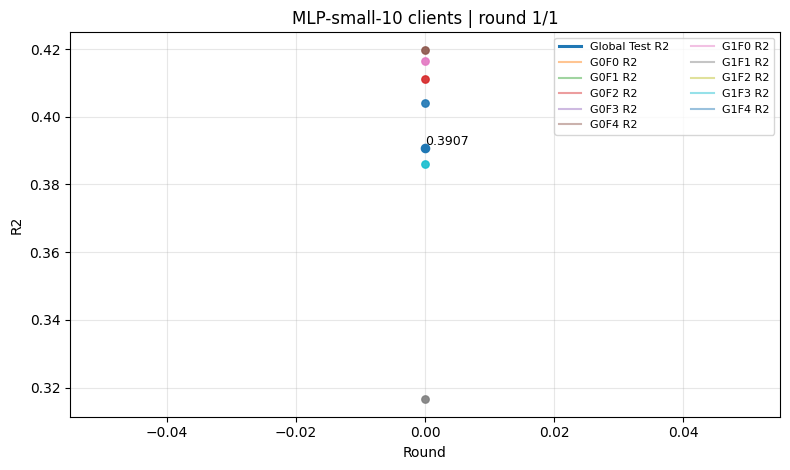

MLP-small-10c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-small-10c | final_r2=0.3907 | tail_std=0.0000

RUN | arch=MLP | size=small | clients=20


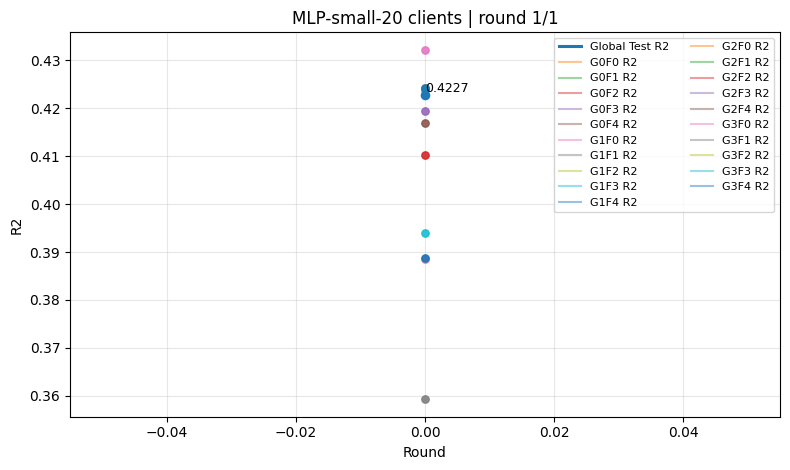

MLP-small-20c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-small-20c | final_r2=0.4227 | tail_std=0.0000

RUN | arch=MLP | size=medium | clients=3


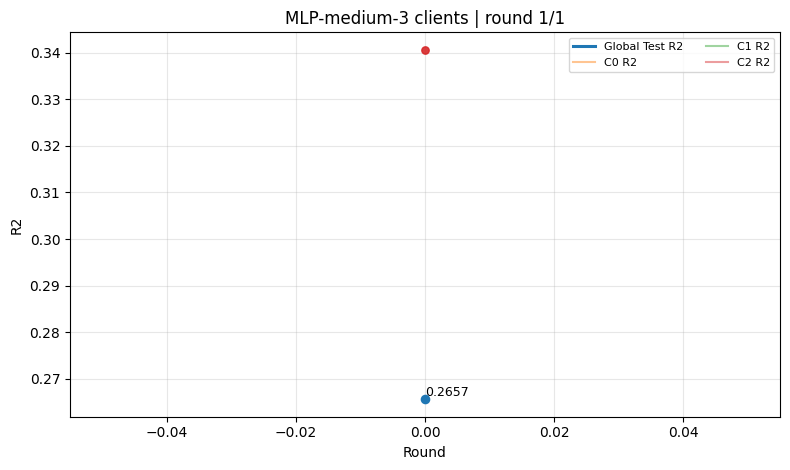

MLP-medium-3c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-medium-3c | final_r2=0.2657 | tail_std=0.0000

RUN | arch=MLP | size=medium | clients=5


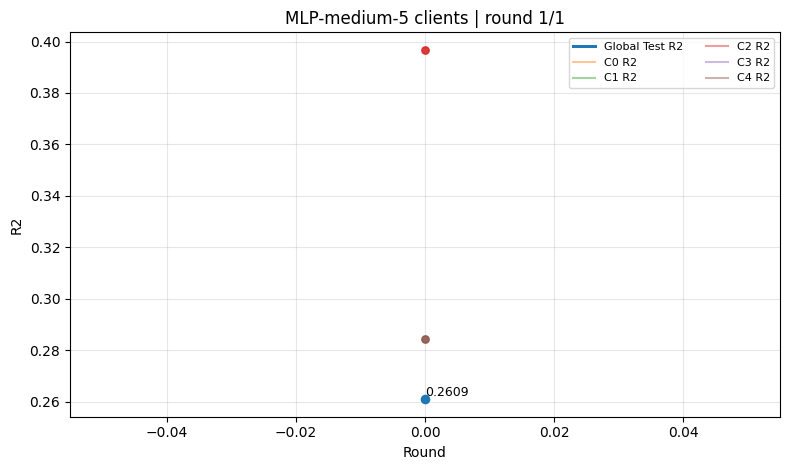

MLP-medium-5c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-medium-5c | final_r2=0.2609 | tail_std=0.0000

RUN | arch=MLP | size=medium | clients=10


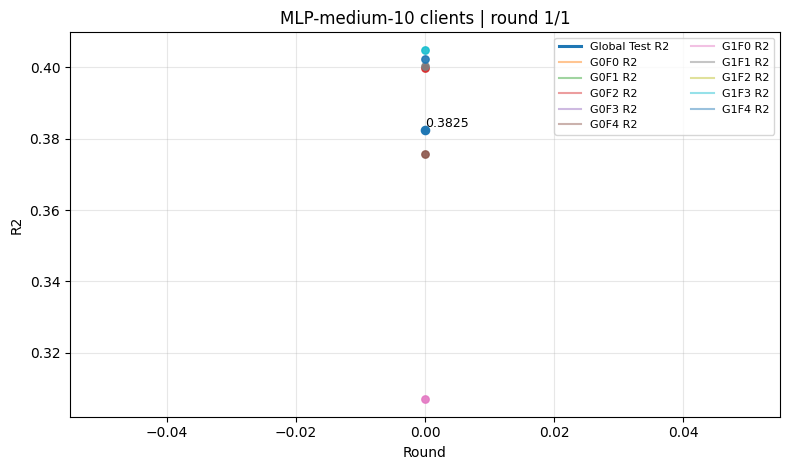

MLP-medium-10c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-medium-10c | final_r2=0.3825 | tail_std=0.0000

RUN | arch=MLP | size=medium | clients=20


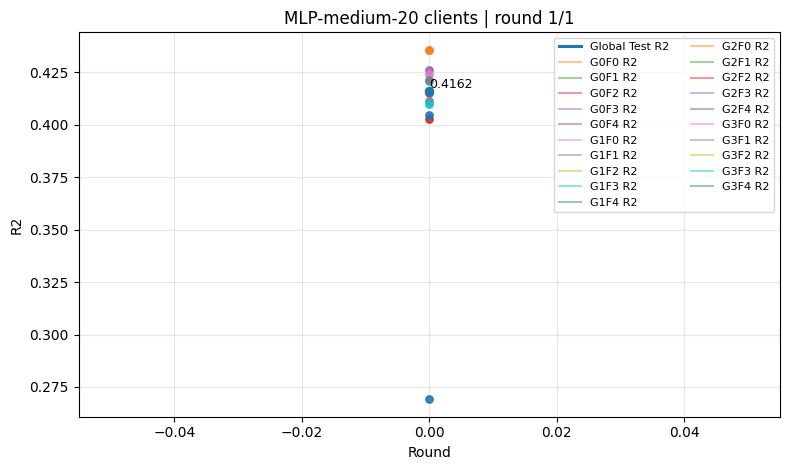

MLP-medium-20c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-medium-20c | final_r2=0.4162 | tail_std=0.0000

RUN | arch=MLP | size=large | clients=3


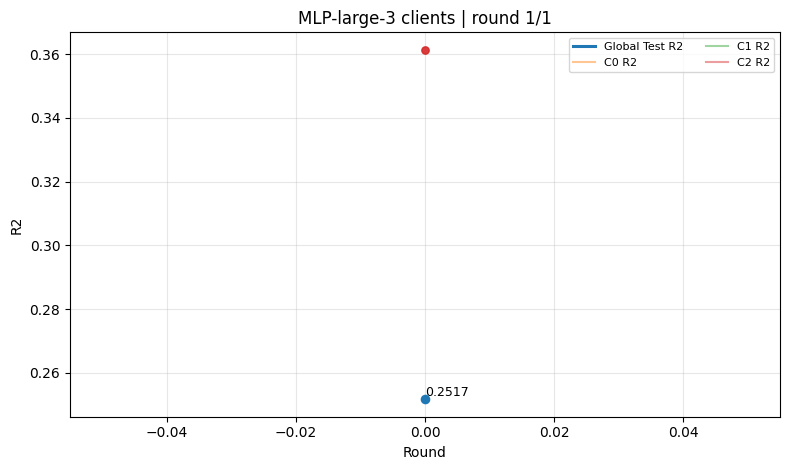

MLP-large-3c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-large-3c | final_r2=0.2517 | tail_std=0.0000

RUN | arch=MLP | size=large | clients=5


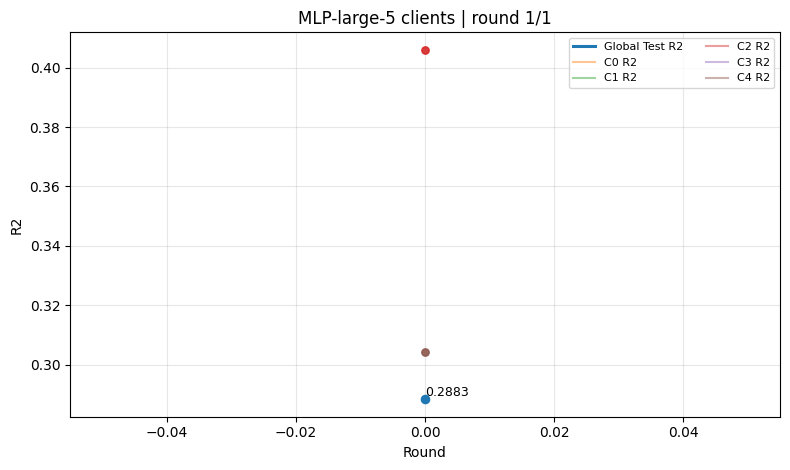

MLP-large-5c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-large-5c | final_r2=0.2883 | tail_std=0.0000

RUN | arch=MLP | size=large | clients=10


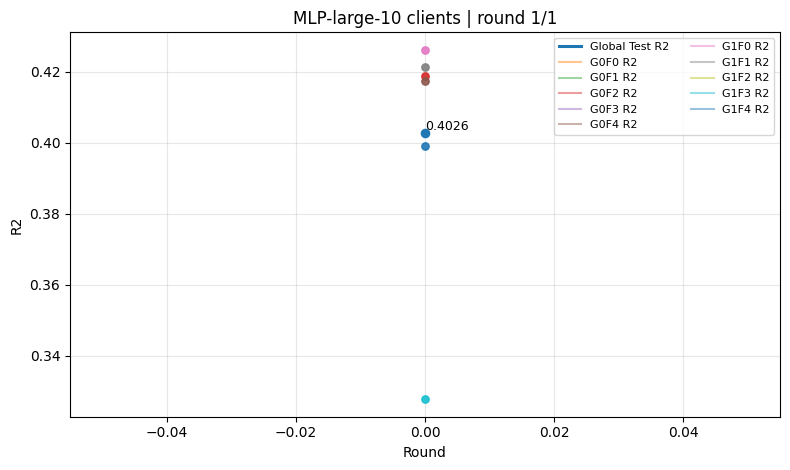

MLP-large-10c:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] MLP-large-10c | final_r2=0.4026 | tail_std=0.0000

RUN | arch=MLP | size=large | clients=20


None

MLP-large-20c:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
df = run_all_experiments()